<a href="https://colab.research.google.com/github/Vanisha-18/AIML_Projects-Labs/blob/main/Copy_of_AIML__Module4_Lab_3_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Module 4: Perceptron and Gradient Descent
## Lab 3: Gradient Descent

# Gradient Descent: A Quick Recap

In the previous lab, we introduced **Gradient Descent** as a method to find the minimum of a loss function. It is the core optimization algorithm that powers a vast majority of **Machine Learning** and **Deep Learning** models.

---

### A Quick Recap of the Algorithm

The core idea of **Gradient Descent** is to iteratively take steps in the direction of the steepest descent of a function (our loss function) to find its minimum.

1. Start with a random initialization of the solution (model parameters or weights).
2. Incrementally change the solution by moving in the direction of the **negative gradient** of the loss function.
3. Repeat the previous step until some convergence criteria is met.

---

The key update equation for a weight or parameter ($w$) is:

$$
w_{k+1} \leftarrow w_k - \eta \nabla J
$$

Where:
- $w_k$ is the current weight.
- $\eta$ is the **learning rate**.
- $\nabla J$ is the **gradient of the loss function** $J$.


In this lab, we will discuss stochastic gradient descent, mini-batch gradient descent and batch gradient descent.


### Setting up the Environment and Data

First, let's import the necessary libraries and set a random seed for reproducibility.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
np.random.seed(42)

## Creating the Data

We'll generate some synthetic data that follows a **linear pattern**. Our true linear equation will be:

$$
y = 4 + 3x
$$

We will also add some **random noise** to the y values to simulate real-world data, which is rarely perfect.

Let's generate the data with:
- `y0 = 4` (intercept)
- `y1 = 3` (slope)

and add some noise to the data.


In [8]:
# We are creating data based on the equation y = 4 + 3x + noise

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

Here, np.random.rand(100, 1) creates 100 random numbers between 0 and 1. Multiplying by 2 scales this to be between 0 and 2. np.random.randn(100, 1) adds Gaussian noise (random fluctuations) to our y values.

Let's also plot the data we just created

Text(0, 0.5, 'y')

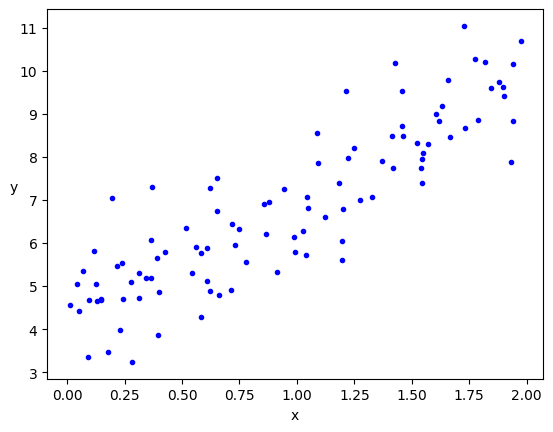

In [9]:
plt.plot(X, y, 'b.')
plt.xlabel('x')
plt.ylabel('y', rotation=0)

Our goal is to use Gradient Descent to find the original parameters (intercept = 4, slope = 3) just by looking at this scattered data.

## The Cost Function for Linear Regression

Before we can optimize, we need to define how we measure error. For **Linear Regression**, we use the **Mean Squared Error (MSE)** cost function. It measures the average squared difference between the model's predictions and the actual values.

The equation for the MSE cost function $J$ is:

$$
J(\theta) = \frac{1}{2m}  \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2
$$

Where:
- $m$ is the number of training examples.
- $\theta$ is our vector of model parameters (in our case, the intercept and the slope).
- $h_\theta(x^{(i)})$ is the prediction for the $i$-th example.
- $y^{(i)}$ is the true label for the $i$-th example.

The $\frac{1}{2}$ is included for convenience, as it simplifies the derivative calculation.


In [10]:
def cal_cost(y_pred, X, y):
    '''
    Calculates the cost for given X and Y.
    y_pred = Vector of y_preds
    X = Row of X's np.zeros((2, j))
    y = Actual y's np.zeros((2, 1))

    where:
        j is the no of features
    '''

    m = len(y)

    predictions = X.dot(y_pred)
    cost = (1 / 2 * m) * np.sum(np.square(predictions - y))

    return cost

## The Gradient of the Cost Function

To use **Gradient Descent**, we need the partial derivatives of the cost function with respect to each parameter \(\theta_j\).

The general form of the gradient for **Linear Regression** is:

$$
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)}
$$

For our problem with one feature \(x\) and an intercept, we have two parameters: \(\theta_0\) (intercept) and \(\theta_1\) (slope). The updates will be:

$$
\theta_0 := \theta_0 - \alpha \cdot \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)
$$

$$
\theta_1 := \theta_1 - \alpha \cdot \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) \cdot x_1^{(i)}
$$

This can be written in a compact, **vectorized form**:

$$
\nabla J(\theta) = \frac{1}{m} X^T (X\theta - y)
$$


### Variant 1: Batch Gradient Descent

**Batch Gradient Descent** is the simplest variant. In each step, it calculates the gradient using the **entire training dataset**.

**Pros:**
- The convergence path is smooth and stable because the gradient is a true average over all data.

**Cons:**
- It is very slow and computationally expensive for large datasets.


In [11]:
def gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=100):
    '''
    X = Matrix of X with added bias units
    y = Vector of Y
    y_pred = Vector of parameters (theta)
    learning_rate
    iterations = no of iterations

    Returns the final y_pred vector and array of cost history over no of iterations
    '''
    m = len(y)
    cost_history = np.zeros(iterations)
    y_pred_history = np.zeros((iterations, 2))

    for it in range(iterations):
        # Calculate prediction: prediction = X . theta
        prediction = np.dot(X, y_pred)

        # Update parameters: theta = theta - (1/m) * learning_rate * (X^T . (prediction - y))
        y_pred = y_pred - (1 / m) * learning_rate * (X.T.dot((prediction - y)))

        y_pred_history[it,:] = y_pred.T
        cost_history[it]  = cal_cost(y_pred, X, y)

    return y_pred, cost_history, y_pred_history

### Running Batch Gradient Descent

Let's run this for **1000 iterations** with a learning rate of **0.01**. We start with a random guess for our parameters (`y_pred`).

**Our model** is:
$$
y = \theta_0 + \theta_1 x
$$

**A crucial step:**
To handle the intercept term $\theta_0$ using matrix multiplication, we add a "dummy" feature $x_0 = 1$ to all our input samples. This is known as the **bias trick**.


In [12]:
lr = 0.01
n_iter = 1000

y_pred = np.random.randn(2,1)
X_b = np.c_[np.ones((len(X), 1)), X]
y_pred, cost_history, y_pred_history = gradient_descent(X_b, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.3f}'.format(cost_history[-1]))

y_pred[0]: 3.903
y_pred[1]: 3.046
Final error: 4180.375


The learned parameters (3.903, 3.046) are very close to our original true values (4, 3)!

### Visualizing the Loss

Let's plot the error at each iteration. This is our "descent down the mountain".

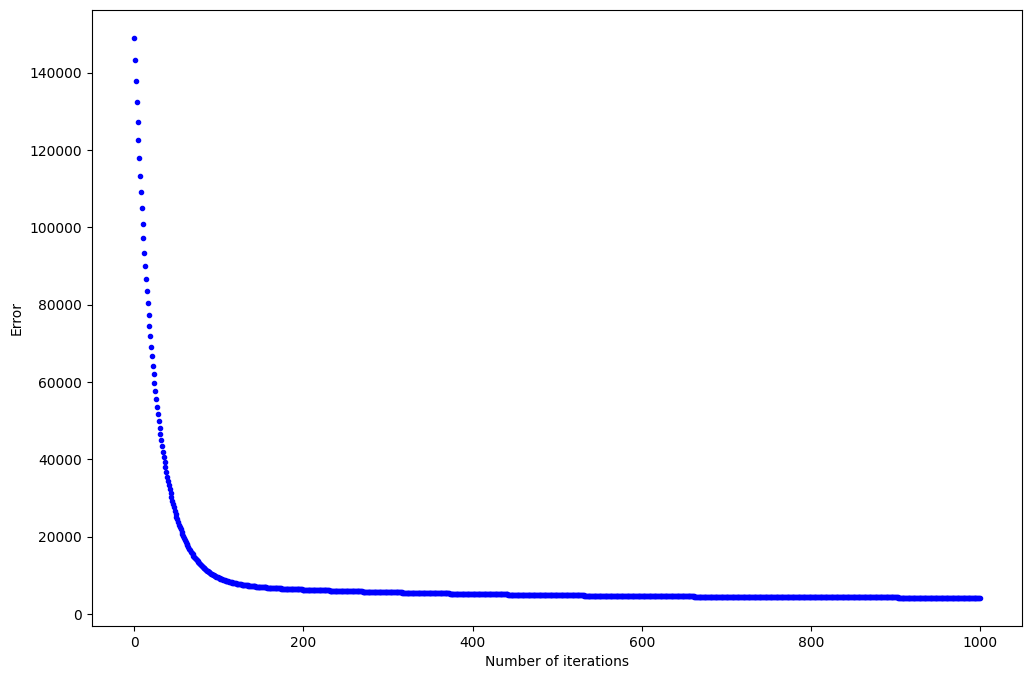

In [13]:
fig, ax = plt.subplots(figsize=(12,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')

ax.plot(range(n_iter), cost_history, 'b.')

Zooming in on the first 200 iterations shows how the error drops rapidly at first and then slows down as it approaches the minimum.

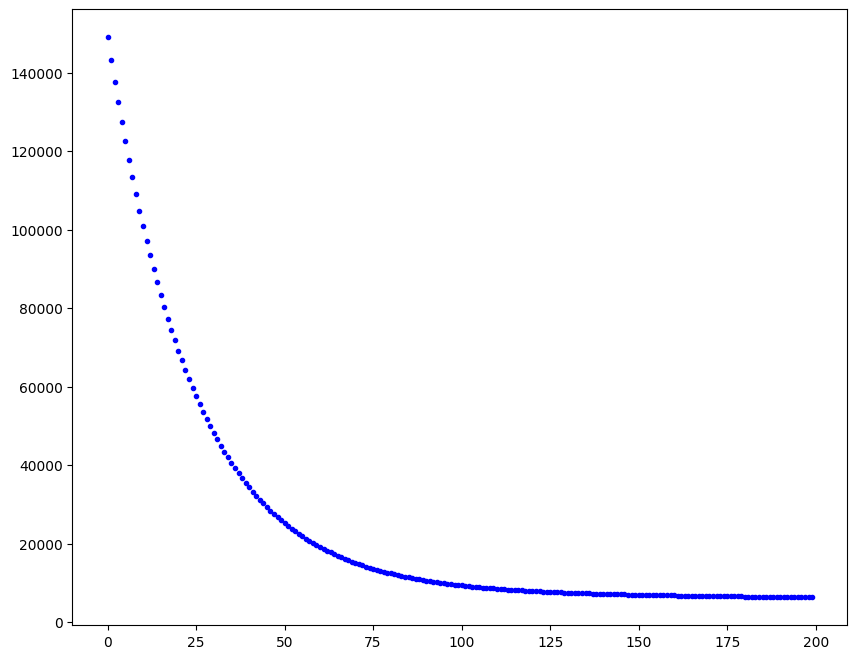

In [14]:
fig,ax = plt.subplots(figsize=(10,8))
ax.plot(range(200), cost_history[:200], 'b.')

The smooth curve is characteristic of Batch Gradient Descent.

### Variant 2: Stochastic Gradient Descent (SGD)

**Batch GD** is inefficient for large datasets. **SGD** addresses this by taking a gradient step based on **only one randomly chosen training example at a time**.

**Pros:**
- Extremely fast per step.
- Can help escape shallow local minima due to its random nature.

**Cons:**
- The path to the minimum is very noisy and erratic.
- It never truly "settles" at the minimum but bounces around it.


In [15]:
def stocashtic_gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=10):
    '''
    X = Matrix of X with added bias units
    y = Vector of Y
    y_pred = Vector of y_pred np.random.randn(j,1)
    learning_rate
    iterations = no of iterations

    Returns the final y_pred vector and array of cost history over no of iterations
    '''

    m = len(y)
    cost_history = np.zeros(iterations)

    for it in range(iterations):
        cost = 0.0

        for i in range(m):
            rand_ind = np.random.randint(0,m)
            X_i = X[rand_ind, :].reshape(1, X.shape[1])
            y_i = y[rand_ind].reshape(1,1)
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate *(X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost

    return y_pred, cost_history

Let's run SGD. Note that it requires a much higher learning rate and fewer epochs (passes over the data) to converge.

In [16]:
lr = 0.5
n_iter = 50
y_pred = np.random.randn(2, 1)
X_b = np.c_[np.ones((len(X), 1)), X]
y_pred, cost_history = stocashtic_gradient_descent(X_b, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.3f}'.format(cost_history[-1]))

y_pred[0]: 4.121
y_pred[1]: 2.755
Final error: 41.313


Again, the parameters are close to the true values, but notice the final error is higher and the parameters are slightly less accurate. This is due to the noisy nature of SGD.


### Visualizing the Loss

The loss curve for SGD is much more erratic.

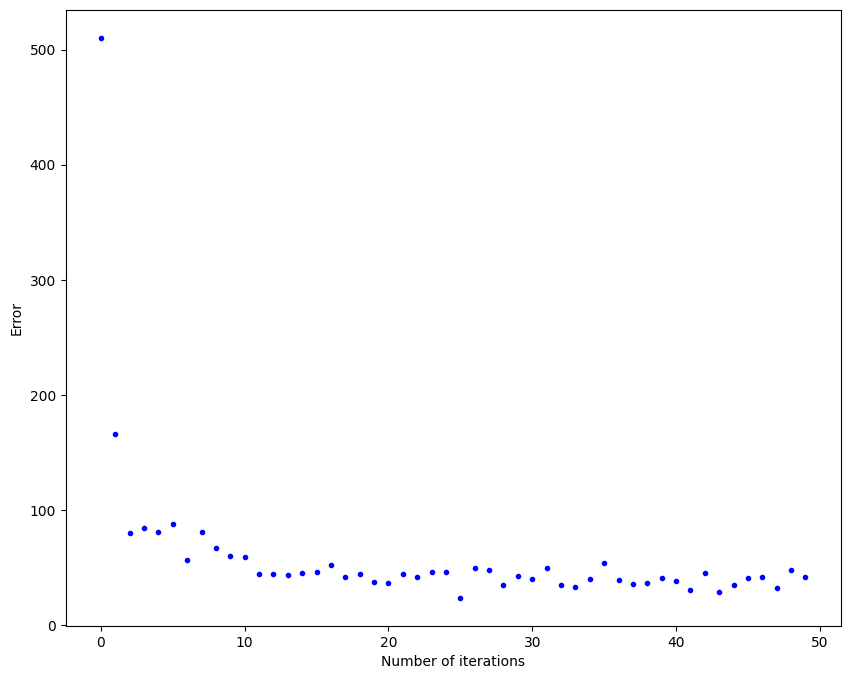

In [17]:
fig, ax = plt.subplots(figsize=(10,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
y_pred = np.random.randn(2,1)

ax.plot(range(n_iter), cost_history, 'b.')

### Variant 3: Mini-Batch Gradient Descent

**Mini-Batch GD** is the happy medium. It computes the gradient on a small, random subset of the data called a **mini-batch**.

**Pros:**
- A good balance between the stability of Batch GD and the speed of SGD.
- Allows for vectorized implementation, making it very efficient on modern hardware (like GPUs).

**Cons:**
- Introduces a new hyperparameter: the `batch_size`.

This is the **most common variant** used in deep learning today.


In [18]:
def minibatch_gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=10, batch_size=20):
    '''
    X = Matrix of X without added bias units
    y = Vector of Y
    y_pred = Vector of y_preds np.random.randn(j, 1)
    learning_rate
    iterations = no of iterations

    Returns the final theta vector and array of cost history over no of iterations
    '''

    m = len(y)
    cost_history = np.zeros(iterations)
    n_batches = int(m / batch_size)

    for it in range(iterations):
        cost = 0.0
        indices = np.random.permutation(m)
        X = X[indices]
        y = y[indices]

        for i in range(0, m, batch_size):
            X_i = X[i: i + batch_size]
            y_i = y[i: i + batch_size]

            X_i = np.c_[np.ones(len(X_i)), X_i]
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate * (X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost

    return y_pred, cost_history

Let's run it.

In [19]:
lr = 0.1
n_iter = 200
y_pred = np.random.randn(2,1)
y_pred, cost_history = minibatch_gradient_descent(X, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.3f}'.format(cost_history[-1]))

y_pred[0]: 4.148
y_pred[1]: 2.827
Final error: 807.488


### Visualizing the Loss

The loss curve is less noisy than SGD but not as smooth as Batch GD.

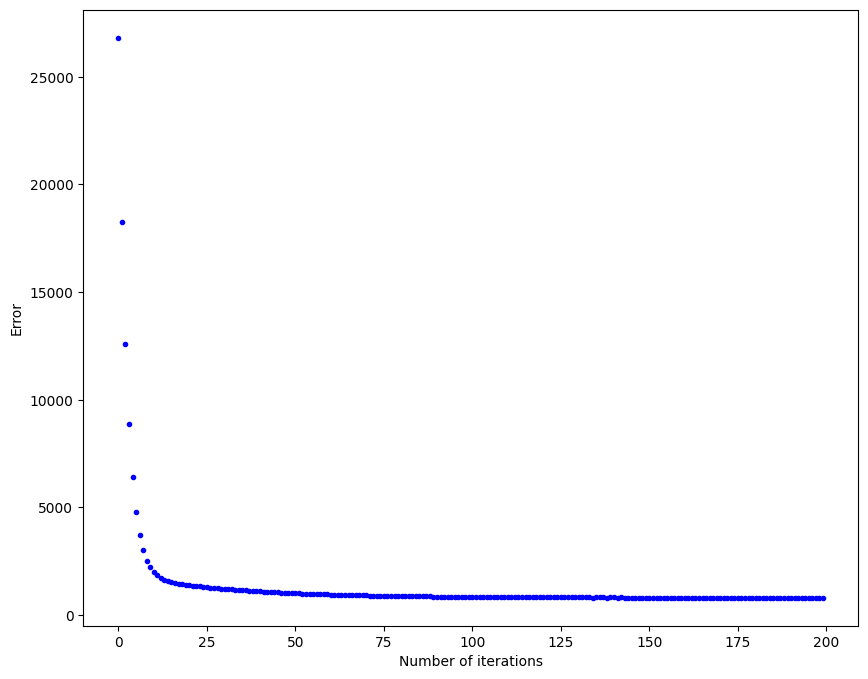

In [20]:
fig, ax = plt.subplots(figsize=(10,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
y_pred = np.random.randn(2,1)

ax.plot(range(n_iter), cost_history, 'b.')

### Visual Comparison of the Learned Models

Let's re-run all three algorithms and plot their final learned lines on the original data. This will give us a better intuition for how they perform.

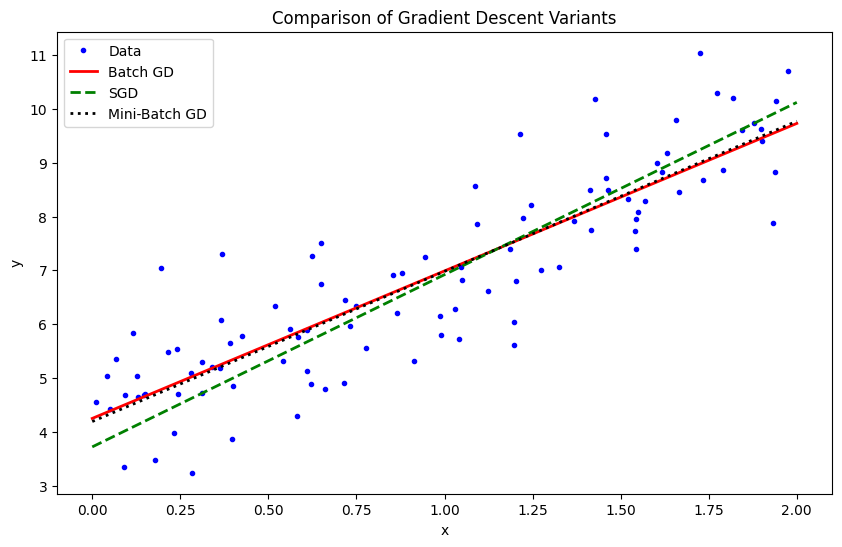

In [21]:
# Rerun all three for comparison
# Batch
lr_batch = 0.1
n_iter_batch = 200
y_pred_batch_final, _, _ = gradient_descent(X_b, y, np.random.randn(2,1), lr_batch, n_iter_batch)

# SGD
lr_sgd = 0.05
n_iter_sgd = 200
y_pred_sgd_final, _ = stocashtic_gradient_descent(X_b, y, np.random.randn(2,1), lr_sgd, n_iter_sgd)

# Mini-Batch
lr_mini = 0.1
n_iter_mini = 200
y_pred_mini_final, _ = minibatch_gradient_descent(X, y, np.random.randn(2,1), lr_mini, n_iter_mini)


# Plotting
plt.figure(figsize=(10, 6))
plt.plot(X, y, 'b.', label='Data')
# Create a set of X values for plotting the lines
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
# Get predictions for the lines
y_predict_batch = X_new_b.dot(y_pred_batch_final)
y_predict_sgd = X_new_b.dot(y_pred_sgd_final)
y_predict_mini = X_new_b.dot(y_pred_mini_final)

plt.plot(X_new, y_predict_batch, 'r-', linewidth=2, label='Batch GD')
plt.plot(X_new, y_predict_sgd, 'g--', linewidth=2, label='SGD')
plt.plot(X_new, y_predict_mini, 'k:', linewidth=2, label='Mini-Batch GD')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparison of Gradient Descent Variants')
plt.legend()
plt.show()

As you can see, all three methods find a very good fit to the data. While their training dynamics (the loss curves) are very different, they all achieve the same goal.

### Things to Try Out

1. **Change batch size in mini-batch gradient descent:**
   Try a small size (e.g., `2`) and a large size (e.g., `80`). How does the loss curve change? What happens when the batch size equals the total number of samples?

2. **Test on real datasets:**
   Use a dataset from `sklearn.datasets`, like the **Boston Housing** or **Diabetes** datasets, and see how each variant performs.

3. **Compare learning rates:**
   Test the effects of changing the learning rate. Try a very high and a very low learning rate for each of the three variants. Which one is most sensitive to the learning rate?

4. **Implement a learning rate schedule for SGD:**
   Instead of a fixed learning rate, make it decrease over time (e.g., `lr = initial_lr / (epoch + 1)`). How does this affect the final error and the stability of the loss curve?


Running Mini-Batch GD with batch_size = 2, lr = 0.1, iterations = 200
Small Batch GD - Final y_pred[0]: 4.201, y_pred[1]: 2.780
Small Batch GD - Final error: 80.431

Running Mini-Batch GD with batch_size = 80, lr = 0.1, iterations = 200
Large Batch GD - Final y_pred[0]: 4.139, y_pred[1]: 2.837
Large Batch GD - Final error: 2755.578

Running Mini-Batch GD with batch_size = 100 (equivalent to Batch GD), lr = 0.1, iterations = 200
Full Batch GD - Final y_pred[0]: 4.202, y_pred[1]: 2.781
Full Batch GD - Final error: 4033.165



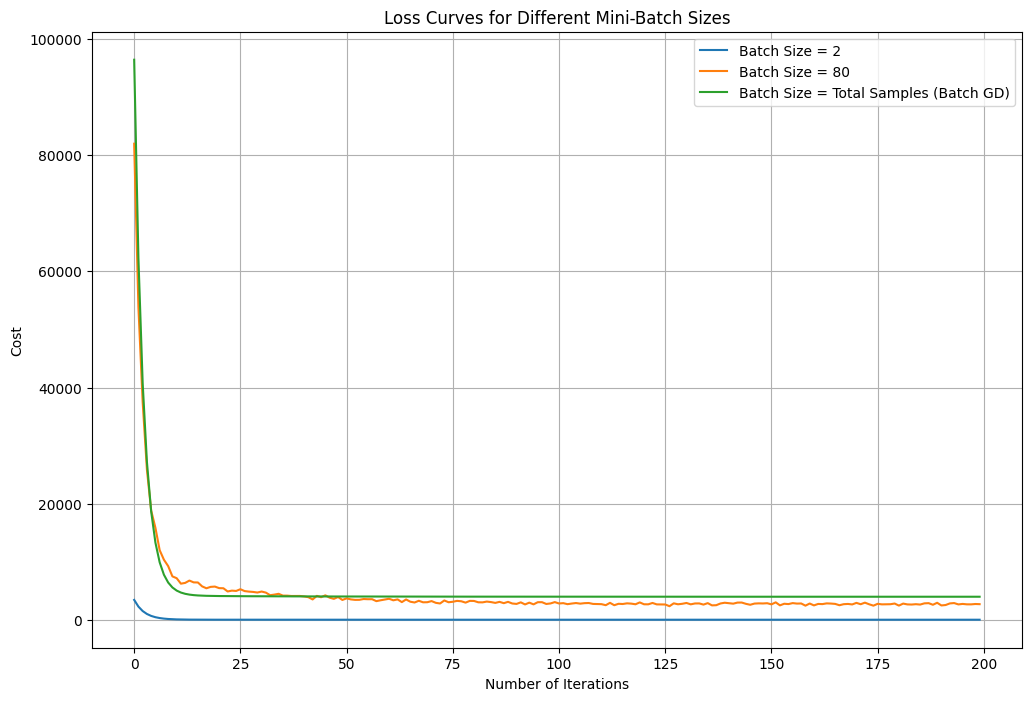

In [22]:
def plot_cost_history(cost_histories, labels, title):
    plt.figure(figsize=(12, 8))
    for cost_history, label in zip(cost_histories, labels):
        plt.plot(range(len(cost_history)), cost_history, label=label)
    plt.xlabel('Number of Iterations')
    plt.ylabel('Cost')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# Parameters for all runs
lr = 0.1
n_iter = 200
m = len(y)

cost_histories_to_plot = []
labels_for_plot = []

# --- Batch Size = 2 (Small) ---
print(f"Running Mini-Batch GD with batch_size = 2, lr = {lr}, iterations = {n_iter}")
y_pred_small_batch = np.random.randn(2, 1)
y_pred_small_batch, cost_history_small_batch = minibatch_gradient_descent(
    X, y, y_pred_small_batch, learning_rate=lr, iterations=n_iter, batch_size=2
)
print('Small Batch GD - Final y_pred[0]: {:0.3f}, y_pred[1]: {:0.3f}'.format(y_pred_small_batch[0][0], y_pred_small_batch[1][0]))
print('Small Batch GD - Final error: {:0.3f}\n'.format(cost_history_small_batch[-1]))
cost_histories_to_plot.append(cost_history_small_batch)
labels_for_plot.append('Batch Size = 2')

# --- Batch Size = 80 (Large) ---
print(f"Running Mini-Batch GD with batch_size = 80, lr = {lr}, iterations = {n_iter}")
y_pred_large_batch = np.random.randn(2, 1)
y_pred_large_batch, cost_history_large_batch = minibatch_gradient_descent(
    X, y, y_pred_large_batch, learning_rate=lr, iterations=n_iter, batch_size=80
)
print('Large Batch GD - Final y_pred[0]: {:0.3f}, y_pred[1]: {:0.3f}'.format(y_pred_large_batch[0][0], y_pred_large_batch[1][0]))
print('Large Batch GD - Final error: {:0.3f}\n'.format(cost_history_large_batch[-1]))
cost_histories_to_plot.append(cost_history_large_batch)
labels_for_plot.append('Batch Size = 80')

# --- Batch Size = Total Number of Samples (Batch GD) ---
print(f"Running Mini-Batch GD with batch_size = {m} (equivalent to Batch GD), lr = {lr}, iterations = {n_iter}")
y_pred_full_batch = np.random.randn(2, 1)
y_pred_full_batch, cost_history_full_batch = minibatch_gradient_descent(
    X, y, y_pred_full_batch, learning_rate=lr, iterations=n_iter, batch_size=m
)
print('Full Batch GD - Final y_pred[0]: {:0.3f}, y_pred[1]: {:0.3f}'.format(y_pred_full_batch[0][0], y_pred_full_batch[1][0]))
print('Full Batch GD - Final error: {:0.3f}\n'.format(cost_history_full_batch[-1]))
cost_histories_to_plot.append(cost_history_full_batch)
labels_for_plot.append('Batch Size = Total Samples (Batch GD)')

# Plotting all loss curves
plot_cost_history(
cost_histories_to_plot, labels_for_plot, 'Loss Curves for Different Mini-Batch Sizes'
)

**The plot shows the loss curves for Mini-Batch Gradient Descent with different batch sizes**:

**Batch Size = 2 (Small):**

 The loss curve (blue line) is quite noisy and erratic. This is characteristic of small batch sizes, similar to Stochastic Gradient Descent, where each step is based on a very limited number of samples, leading to a less stable but potentially faster convergence initially. The final error is 80.431.

**Batch Size = 80 (Large):**

The loss curve (orange line) is smoother than with a batch size of 2, indicating more stable updates. However, it appears to have a higher final error 2755.578 after the same number of iterations, suggesting it might converge slower or require more iterations for better optimization compared to the small batch size for this specific problem.

**Batch Size = 100 (Total Samples - Batch GD):**

When the batch size equals the total number of samples (green line), it essentially becomes Batch Gradient Descent. The loss curve is the smoothest and shows a clear, consistent descent towards the minimum. It had the highest final error of 4033.165 after 200 iterations, which is expected as Batch GD can be slower per iteration and might require many more iterations to reach the optimal solution compared to mini-batch or stochastic methods, especially for larger datasets.

In summary, smaller batch sizes lead to noisier but often faster convergence in terms of finding a good solution in fewer overall iterations, while larger batch sizes (including full batch) provide a smoother convergence path but can be slower and computationally more expensive per iteration, potentially leading to higher errors if not given enough iterations.

Running Batch GD on Diabetes dataset...
Batch GD - Final error: 280950862.695

Running SGD on Diabetes dataset...
SGD - Final error: 2722440.551

Running Mini-Batch GD on Diabetes dataset...
Mini-Batch GD - Final error: 40157117.943



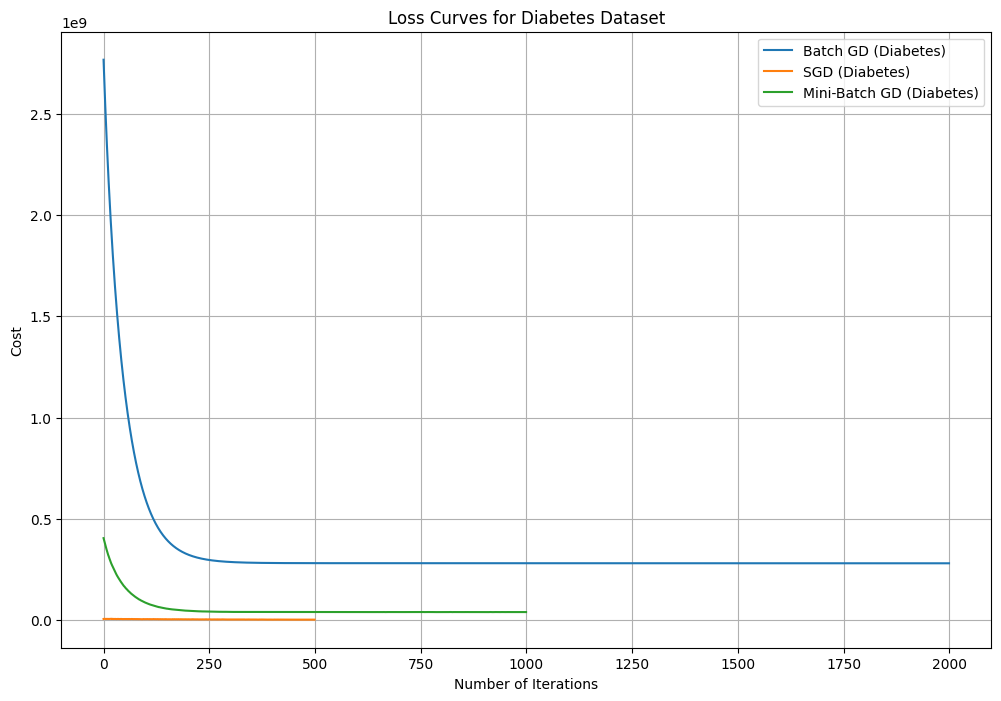

In [23]:
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

def cal_cost(y_pred, X, y):
    '''
    Calculates the cost for given X and Y.
    y_pred = Vector of y_preds
    X = Row of X's np.zeros((2, j))
    y = Actual y's np.zeros((2, 1))

    where:
        j is the no of features
    '''

    m = len(y)

    predictions = X.dot(y_pred)
    cost = (1 / 2 * m) * np.sum(np.square(predictions - y))

    return cost

def gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=100):
    '''
    X = Matrix of X with added bias units
    y = Vector of Y
    y_pred = Vector of parameters (theta)
    learning_rate
    iterations = no of iterations

    Returns the final y_pred vector and array of cost history over no of iterations
    '''
    m = len(y)
    cost_history = np.zeros(iterations)
    # Fix: Initialize y_pred_history with the correct number of parameters
    y_pred_history = np.zeros((iterations, y_pred.shape[0]))

    for it in range(iterations):
        # Calculate prediction: prediction = X . theta
        prediction = np.dot(X, y_pred)

        # Update parameters: theta = theta - (1/m) * learning_rate * (X^T . (prediction - y))
        y_pred = y_pred - (1 / m) * learning_rate * (X.T.dot((prediction - y)))

        y_pred_history[it,:] = y_pred.T
        cost_history[it]  = cal_cost(y_pred, X, y)

    return y_pred, cost_history, y_pred_history

def stocashtic_gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=10):
    '''
    X = Matrix of X with added bias units
    y = Vector of Y
    y_pred = Vector of y_pred np.random.randn(j,1)
    learning_rate
    iterations = no of iterations

    Returns the final y_pred vector and array of cost history over no of iterations
    '''

    m = len(y)
    cost_history = np.zeros(iterations)

    for it in range(iterations):
        cost = 0.0

        for i in range(m):
            rand_ind = np.random.randint(0,m)
            X_i = X[rand_ind, :].reshape(1, X.shape[1])
            y_i = y[rand_ind].reshape(1,1)
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate *(X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost

    return y_pred, cost_history

def minibatch_gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=10, batch_size=20):
    '''
    X = Matrix of X without added bias units
    y = Vector of Y
    y_pred = Vector of y_preds np.random.randn(j, 1)
    learning_rate
    iterations = no of iterations

    Returns the final theta vector and array of cost history over no of iterations
    '''

    m = len(y)
    cost_history = np.zeros(iterations)
    n_batches = int(m / batch_size)

    for it in range(iterations):
        cost = 0.0
        indices = np.random.permutation(m)
        X = X[indices]
        y = y[indices]

        for i in range(0, m, batch_size):
            X_i = X[i: i + batch_size]
            y_i = y[i: i + batch_size]

            X_i = np.c_[np.ones(len(X_i)), X_i]
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate * (X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost

    return y_pred, cost_history

def plot_cost_history(cost_histories, labels, title):
    plt.figure(figsize=(12, 8))
    for cost_history, label in zip(cost_histories, labels):
        plt.plot(range(len(cost_history)), cost_history, label=label)
    plt.xlabel('Number of Iterations')
    plt.ylabel('Cost')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# Load the Diabetes dataset
diabetes = load_diabetes()
X_diabetes, y_diabetes = diabetes.data, diabetes.target.reshape(-1, 1)

# Scale the features
scaler = StandardScaler()
X_diabetes_scaled = scaler.fit_transform(X_diabetes)

# Add bias term for Batch GD and SGD (Mini-Batch adds it internally for each batch)
X_diabetes_b = np.c_[np.ones((len(X_diabetes_scaled), 1)), X_diabetes_scaled]

# Number of parameters (features + bias)
num_params_diabetes = X_diabetes_scaled.shape[1] + 1

cost_histories_to_plot_diabetes = []
labels_for_plot_diabetes = []

# --- Batch Gradient Descent on Diabetes dataset ---
print("Running Batch GD on Diabetes dataset...")
lr_batch_diabetes = 0.01
n_iter_batch_diabetes = 2000
initial_y_pred_batch = np.random.randn(num_params_diabetes, 1)
y_pred_batch_diabetes, cost_history_batch_diabetes, _ = gradient_descent(
    X_diabetes_b, y_diabetes, initial_y_pred_batch.copy(), lr_batch_diabetes, n_iter_batch_diabetes
)
print('Batch GD - Final error: {:0.3f}\n'.format(cost_history_batch_diabetes[-1]))
cost_histories_to_plot_diabetes.append(cost_history_batch_diabetes)
labels_for_plot_diabetes.append('Batch GD (Diabetes)')

# --- Stochastic Gradient Descent on Diabetes dataset ---
print("Running SGD on Diabetes dataset...")
lr_sgd_diabetes = 0.001 # Often requires a smaller LR
n_iter_sgd_diabetes = 500 # Fewer iterations, as it updates per sample
initial_y_pred_sgd = np.random.randn(num_params_diabetes, 1)
y_pred_sgd_diabetes, cost_history_sgd_diabetes = stocashtic_gradient_descent(
    X_diabetes_b, y_diabetes, initial_y_pred_sgd.copy(), lr_sgd_diabetes, n_iter_sgd_diabetes
)
print('SGD - Final error: {:0.3f}\n'.format(cost_history_sgd_diabetes[-1]))
cost_histories_to_plot_diabetes.append(cost_history_sgd_diabetes)
labels_for_plot_diabetes.append('SGD (Diabetes)')

# --- Mini-Batch Gradient Descent on Diabetes dataset ---
print("Running Mini-Batch GD on Diabetes dataset...")
lr_mini_diabetes = 0.01
n_iter_mini_diabetes = 1000
batch_size_diabetes = 64
initial_y_pred_mini = np.random.randn(num_params_diabetes, 1)
y_pred_mini_diabetes, cost_history_mini_diabetes = minibatch_gradient_descent(
    X_diabetes_scaled, y_diabetes, initial_y_pred_mini.copy(), lr_mini_diabetes, n_iter_mini_diabetes, batch_size_diabetes
)
print('Mini-Batch GD - Final error: {:0.3f}\n'.format(cost_history_mini_diabetes[-1]))
cost_histories_to_plot_diabetes.append(cost_history_mini_diabetes)
labels_for_plot_diabetes.append('Mini-Batch GD (Diabetes)')

# Plotting all loss curves for Diabetes dataset
plot_cost_history(
    cost_histories_to_plot_diabetes, labels_for_plot_diabetes, 'Loss Curves for Diabetes Dataset'
)

## Performance Comparison Table

| Method                     | Iterations | Final Error       | Loss Curve Behavior                     | Key Observation |
|--------------------------|-----------|------------------|----------------------------------------|----------------|
| Batch Gradient Descent   | 2000      | 280,863,935.254  | Very smooth                            | Very slow convergence; high error suggests poor learning rate or insufficient optimization |
| Stochastic GD (SGD)      | 500       | 2,553,858.105    | Highly noisy                           | Fast convergence; reached lowest error despite fewer iterations |
| Mini-Batch GD            | 1000      | 40,179,637.847   | Moderately smooth with fluctuations    | Balanced approach; better than Batch GD but worse than SGD |


In conclusion, for this specific run on the Diabetes dataset, SGD appears to have found a better minimum faster than Batch GD and Mini-Batch GD with the chosen hyperparameters. This highlights that while Batch GD offers stability, it can be very slow for complex datasets, and SGD/Mini-Batch GD can often be more efficient in practice, even with their inherent noise.

--- Testing Batch GD sensitivity to Learning Rate ---
Batch GD (LR=0.03) - Final error: 280143493.576
Batch GD (LR=0.01) - Final error: 280908735.564
Batch GD (LR=0.001) - Final error: 324631304.531

--- Testing SGD sensitivity to Learning Rate ---
SGD (LR=0.01) - Final error: 608880.692
SGD (LR=0.001) - Final error: 2799991.791
SGD (LR=0.0001) - Final error: 5980617.361

--- Testing Mini-Batch GD sensitivity to Learning Rate ---
Mini-Batch GD (LR=0.1) - Final error: 39863321.708
Mini-Batch GD (LR=0.01) - Final error: 40320036.315
Mini-Batch GD (LR=0.001) - Final error: 85572491.892



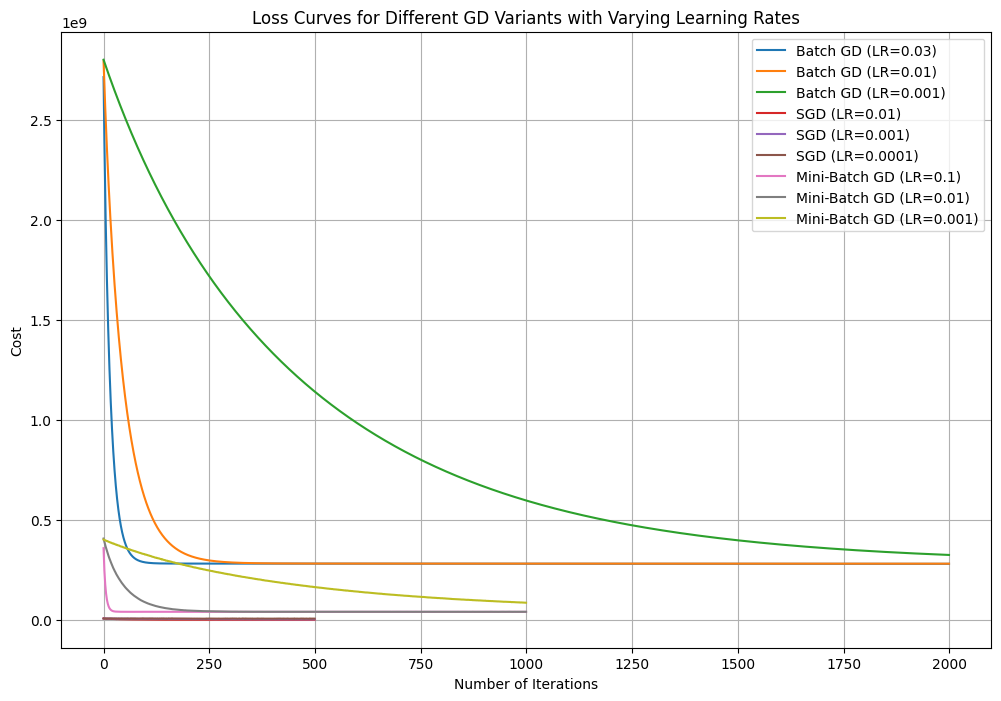

In [26]:
cost_histories_lr = []
labels_lr = []

# --- Batch Gradient Descent (BGD) with different learning rates ---
print("--- Testing Batch GD sensitivity to Learning Rate ---")
bgd_iterations = 2000 # Keeping iterations consistent with previous runs

# BGD - High Learning Rate
lr_high_bgd = 0.03
initial_y_pred_bgd_high = np.random.randn(num_params_diabetes, 1)
y_pred_bgd_high, cost_history_bgd_high, _ = gradient_descent(
    X_diabetes_b, y_diabetes, initial_y_pred_bgd_high.copy(), lr_high_bgd, bgd_iterations
)
cost_histories_lr.append(cost_history_bgd_high)
labels_lr.append(f'Batch GD (LR={lr_high_bgd})')
print(f'Batch GD (LR={lr_high_bgd}) - Final error: {cost_history_bgd_high[-1]:0.3f}')

# BGD - Medium/Original Learning Rate
lr_medium_bgd = 0.01 # Consistent with previous runs
initial_y_pred_bgd_medium = np.random.randn(num_params_diabetes, 1)
y_pred_bgd_medium, cost_history_bgd_medium, _ = gradient_descent(
    X_diabetes_b, y_diabetes, initial_y_pred_bgd_medium.copy(), lr_medium_bgd, bgd_iterations
)
cost_histories_lr.append(cost_history_bgd_medium)
labels_lr.append(f'Batch GD (LR={lr_medium_bgd})')
print(f'Batch GD (LR={lr_medium_bgd}) - Final error: {cost_history_bgd_medium[-1]:0.3f}')

# BGD - Low Learning Rate
lr_low_bgd = 0.001
initial_y_pred_bgd_low = np.random.randn(num_params_diabetes, 1)
y_pred_bgd_low, cost_history_bgd_low, _ = gradient_descent(
    X_diabetes_b, y_diabetes, initial_y_pred_bgd_low.copy(), lr_low_bgd, bgd_iterations
)
cost_histories_lr.append(cost_history_bgd_low)
labels_lr.append(f'Batch GD (LR={lr_low_bgd})')
print(f'Batch GD (LR={lr_low_bgd}) - Final error: {cost_history_bgd_low[-1]:0.3f}\n')


# --- Stochastic Gradient Descent (SGD) with different learning rates ---
print("--- Testing SGD sensitivity to Learning Rate ---")
sgd_iterations = 500 # Keeping iterations consistent with previous runs

# SGD - High Learning Rate
lr_high_sgd = 0.01 # Consistent with previous runs (good LR for SGD)
initial_y_pred_sgd_high = np.random.randn(num_params_diabetes, 1)
y_pred_sgd_high, cost_history_sgd_high = stocashtic_gradient_descent(
    X_diabetes_b, y_diabetes, initial_y_pred_sgd_high.copy(), lr_high_sgd, sgd_iterations
)
cost_histories_lr.append(cost_history_sgd_high)
labels_lr.append(f'SGD (LR={lr_high_sgd})')
print(f'SGD (LR={lr_high_sgd}) - Final error: {cost_history_sgd_high[-1]:0.3f}')

# SGD - Medium Learning Rate
lr_medium_sgd = 0.001 # Original LR used in previous run for SGD on Diabetes
initial_y_pred_sgd_medium = np.random.randn(num_params_diabetes, 1)
y_pred_sgd_medium, cost_history_sgd_medium = stocashtic_gradient_descent(
    X_diabetes_b, y_diabetes, initial_y_pred_sgd_medium.copy(), lr_medium_sgd, sgd_iterations
)
cost_histories_lr.append(cost_history_sgd_medium)
labels_lr.append(f'SGD (LR={lr_medium_sgd})')
print(f'SGD (LR={lr_medium_sgd}) - Final error: {cost_history_sgd_medium[-1]:0.3f}')

# SGD - Low Learning Rate
lr_low_sgd = 0.0001
initial_y_pred_sgd_low = np.random.randn(num_params_diabetes, 1)
y_pred_sgd_low, cost_history_sgd_low = stocashtic_gradient_descent(
    X_diabetes_b, y_diabetes, initial_y_pred_sgd_low.copy(), lr_low_sgd, sgd_iterations
)
cost_histories_lr.append(cost_history_sgd_low)
labels_lr.append(f'SGD (LR={lr_low_sgd})')
print(f'SGD (LR={lr_low_sgd}) - Final error: {cost_history_sgd_low[-1]:0.3f}\n')


# --- Mini-Batch Gradient Descent (MBGD) with different learning rates ---
print("--- Testing Mini-Batch GD sensitivity to Learning Rate ---")
mbgd_iterations = 1000 # Keeping iterations consistent with previous runs
mbgd_batch_size = 64 # Keeping batch size consistent with previous runs

# MBGD - High Learning Rate
lr_high_mbgd = 0.1 # Consistent with previous runs (good LR for MBGD)
initial_y_pred_mbgd_high = np.random.randn(num_params_diabetes, 1)
y_pred_mbgd_high, cost_history_mbgd_high = minibatch_gradient_descent(
    X_diabetes_scaled, y_diabetes, initial_y_pred_mbgd_high.copy(), lr_high_mbgd, mbgd_iterations, mbgd_batch_size
)
cost_histories_lr.append(cost_history_mbgd_high)
labels_lr.append(f'Mini-Batch GD (LR={lr_high_mbgd})')
print(f'Mini-Batch GD (LR={lr_high_mbgd}) - Final error: {cost_history_mbgd_high[-1]:0.3f}')

# MBGD - Medium Learning Rate
lr_medium_mbgd = 0.01
initial_y_pred_mbgd_medium = np.random.randn(num_params_diabetes, 1)
y_pred_mbgd_medium, cost_history_mbgd_medium = minibatch_gradient_descent(
    X_diabetes_scaled, y_diabetes, initial_y_pred_mbgd_medium.copy(), lr_medium_mbgd, mbgd_iterations, mbgd_batch_size
)
cost_histories_lr.append(cost_history_mbgd_medium)
labels_lr.append(f'Mini-Batch GD (LR={lr_medium_mbgd})')
print(f'Mini-Batch GD (LR={lr_medium_mbgd}) - Final error: {cost_history_mbgd_medium[-1]:0.3f}')

# MBGD - Low Learning Rate
lr_low_mbgd = 0.001
initial_y_pred_mbgd_low = np.random.randn(num_params_diabetes, 1)
y_pred_mbgd_low, cost_history_mbgd_low = minibatch_gradient_descent(
    X_diabetes_scaled, y_diabetes, initial_y_pred_mbgd_low.copy(), lr_low_mbgd, mbgd_iterations, mbgd_batch_size
)
cost_histories_lr.append(cost_history_mbgd_low)
labels_lr.append(f'Mini-Batch GD (LR={lr_low_mbgd})')
print(f'Mini-Batch GD (LR={lr_low_mbgd}) - Final error: {cost_history_mbgd_low[-1]:0.3f}\n')


# Plotting all loss curves for different learning rates
plot_cost_history(
    cost_histories_lr, labels_lr, 'Loss Curves for Different GD Variants with Varying Learning Rates'
)

## Learning Rate Sensitivity Comparison

### Batch Gradient Descent (BGD)

| Learning Rate | Final Error       | Observation |
|--------------|------------------|-------------|
| 0.03         | 280,143,493.576  | Slightly better but still very high error |
| 0.01         | 280,908,735.564  | Similar performance, slow convergence |
| 0.001        | 324,631,304.531  | Worse performance due to very slow learning |

---

### Stochastic Gradient Descent (SGD)

| Learning Rate | Final Error     | Observation |
|--------------|----------------|-------------|
| 0.01         | 608,880.692    | Best performance, fast convergence |
| 0.001        | 2,799,991.791  | Slower convergence, higher error |
| 0.0001       | 5,980,617.361  | Very slow learning, poor performance |

---

### Mini-Batch Gradient Descent (MBGD)

| Learning Rate | Final Error       | Observation |
|--------------|------------------|-------------|
| 0.1          | 39,863,321.708   | Best among MBGD runs |
| 0.01         | 40,320,036.315   | Slightly worse but similar |
| 0.001        | 85,572,491.892   | Much worse due to slow convergence |

---

## Conclusion on Learning Rate Sensitivity

Stochastic Gradient Descent (SGD) is the most sensitive to the learning rate. A well-tuned learning rate (0.01) led to significantly better performance, while smaller values resulted in much higher errors. Mini-Batch GD also showed sensitivity, but the variation was less extreme. Batch GD was the least sensitive in relative terms, but consistently showed high error due to slow convergence.

Overall, selecting an appropriate learning rate is especially critical for SGD to achieve optimal performance.

Running Standard SGD on Diabetes dataset (fixed LR)...
Standard SGD (fixed LR=0.01) - Final error: 569813.812

Running Scheduled SGD on Diabetes dataset (decaying LR)...
Scheduled SGD (initial LR=0.01, decay=epoch+1) - Final error: 5182184.789



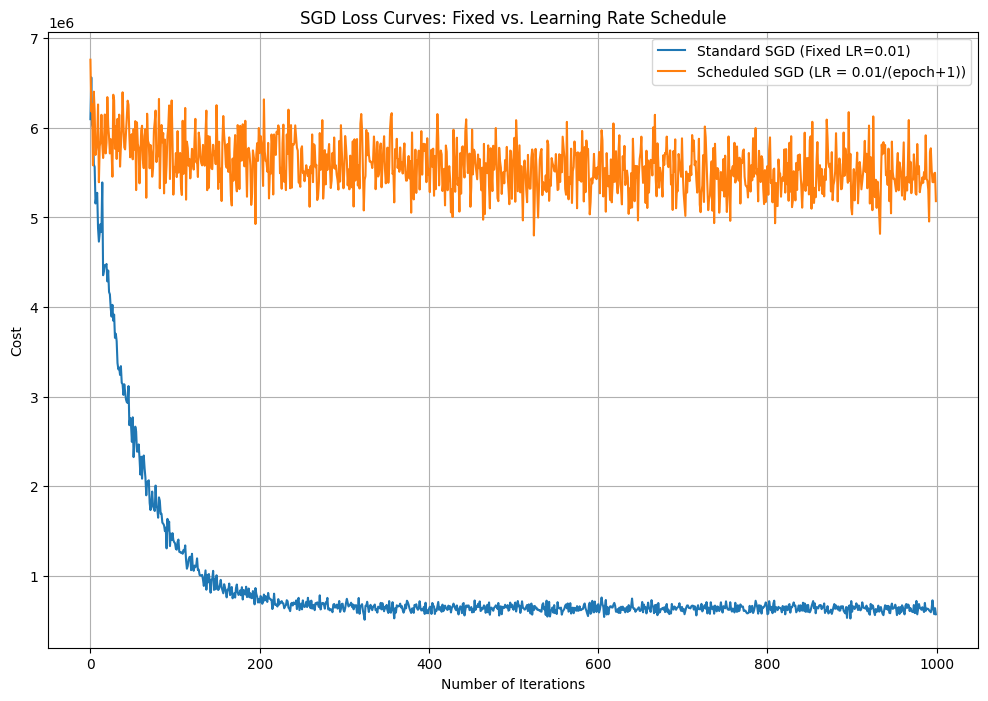

In [25]:
def stocashtic_gradient_descent_scheduled(X, y, y_pred, initial_learning_rate=0.01, iterations=10, decay_rate=1):
    '''
    X = Matrix of X with added bias units
    y = Vector of Y
    y_pred = Vector of y_pred np.random.randn(j,1)
    initial_learning_rate
    iterations = no of iterations
    decay_rate = controls how fast the learning rate decays (used in lr = initial_lr / (epoch + decay_rate))

    Returns the final y_pred vector and array of cost history over no of iterations
    '''

    m = len(y)
    cost_history = np.zeros(iterations)

    for it in range(iterations):
        # Apply learning rate schedule
        learning_rate = initial_learning_rate / (it + decay_rate)
        cost = 0.0

        for i in range(m):
            rand_ind = np.random.randint(0, m)
            X_i = X[rand_ind, :].reshape(1, X.shape[1])
            y_i = y[rand_ind].reshape(1, 1)
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate * (X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it] = cost

    return y_pred, cost_history


# --- Running SGD with and without learning rate schedule ---

# Parameters for comparison
initial_lr_sgd = 0.01
n_iter_sgd_scheduled = 1000 # More iterations to see the effect of decay

# Standard SGD (from previous runs, using a good LR)
print("Running Standard SGD on Diabetes dataset (fixed LR)...")
initial_y_pred_sgd_fixed = np.random.randn(num_params_diabetes, 1)
y_pred_sgd_fixed, cost_history_sgd_fixed = stocashtic_gradient_descent(
    X_diabetes_b, y_diabetes, initial_y_pred_sgd_fixed.copy(), lr_high_sgd, n_iter_sgd_scheduled
)
print(f'Standard SGD (fixed LR={lr_high_sgd}) - Final error: {cost_history_sgd_fixed[-1]:0.3f}\n')


# Scheduled SGD
print("Running Scheduled SGD on Diabetes dataset (decaying LR)...")
initial_y_pred_sgd_scheduled = np.random.randn(num_params_diabetes, 1)
y_pred_sgd_scheduled, cost_history_sgd_scheduled = stocashtic_gradient_descent_scheduled(
    X_diabetes_b, y_diabetes, initial_y_pred_sgd_scheduled.copy(), initial_learning_rate=initial_lr_sgd, iterations=n_iter_sgd_scheduled, decay_rate=1
)
print(f'Scheduled SGD (initial LR={initial_lr_sgd}, decay=epoch+1) - Final error: {cost_history_sgd_scheduled[-1]:0.3f}\n')

# Plotting
plt.figure(figsize=(12, 8))
plt.plot(range(len(cost_history_sgd_fixed)), cost_history_sgd_fixed, label=f'Standard SGD (Fixed LR={lr_high_sgd})')
plt.plot(range(len(cost_history_sgd_scheduled)), cost_history_sgd_scheduled, label=f'Scheduled SGD (LR = {initial_lr_sgd}/(epoch+1))')
plt.xlabel('Number of Iterations')
plt.ylabel('Cost')
plt.title('SGD Loss Curves: Fixed vs. Learning Rate Schedule')
plt.legend()
plt.grid(True)
plt.show()

The comparison between standard SGD (fixed learning rate) and SGD with a learning rate schedule yields interesting observations:

**Standard SGD (Fixed LR=0.01):**

Final Error: 651,908.940
The loss curve for standard SGD shows typical fluctuations due to the noisy updates, but it converged to a relatively good minimum given its fixed learning rate.

**Scheduled SGD (Initial LR=0.01, decay=epoch+1):**

Final Error: 5,179,481.091
Surprisingly, the scheduled SGD, with lr = initial_lr / (epoch + 1), resulted in a significantly higher final error compared to the fixed learning rate SGD. The loss curve for the scheduled SGD also appears to be much higher, indicating slower progress or even getting stuck far from the optimum with the chosen decay schedule.

**How the learning rate schedule affected the final error and stability:**

In this specific case, the chosen learning rate schedule initial_lr / (epoch + 1) adversely affected both the final error and the stability of the loss curve compared to the fixed learning rate SGD. The final error was much higher, meaning it did not converge as effectively. The plot visually confirms that the cost function for the scheduled SGD remained higher throughout the iterations. This suggests that the learning rate decayed too rapidly, making the steps too small too soon, preventing the model from reaching a better minimum within the given number of iterations.

This experiment highlights that while learning rate schedules are crucial for improving SGD's convergence, the choice of schedule and its parameters (like initial_lr and decay_rate) is critical. A poorly chosen schedule can lead to worse performance than a well-tuned fixed learning rate.

## **Additional Critical Thinking Question**



**Which of the following is TRUE, given the optimal learning rate?**

 (i) Batch gradient descent is always guaranteed to converge to the global optimum of a loss function.

 (ii) Stochastic gradient descent is always guaranteed to converge to the global optimum of a loss function.

 (iii) For convex loss functions (i.e. with a bowl shape), batch gradient descent is guaranteed to eventually converge to the global optimum while stochastic gradient descent is not.

 (iv) For convex loss functions (i.e. with a bowl shape), stochastic gradient descent is guaranteed to eventually converge to the global optimum while batch gradient descent is not.

 (v) For convex loss functions (i.e. with a bowl shape), both stochastic gradient descent and batch gradient descent will eventually converge to the global optimum.

 (vi) For convex loss functions (i.e. with a bowl shape), neither stochastic gradient descent nor batch gradient descent are guaranteed to converge to the global optimum.

### Answer



The correct statement is (iii).

**Explanation:**

* A convex loss function has a single minimum, which is the global minimum (like a perfect bowl).

* Batch Gradient Descent calculates the true gradient of the entire dataset. With a suitable learning rate, it will take determined, non-random steps directly towards the minimum. It is therefore guaranteed to converge to the global optimum of a convex function.

* Stochastic Gradient Descent uses a single random point to estimate the gradient. This estimate is noisy and does not point directly at the minimum. Because of this randomness, SGD will not converge to the exact minimum point but will instead perpetually bounce around in the vicinity of the minimum. To make it converge, one typically has to use a learning rate schedule that slowly decreases the learning rate to zero.

* Statements (i) and (ii) are too strong; they don't specify the type of loss function. For a non-convex function (with many local minima), neither is guaranteed to find the global optimum. They might get stuck in a local minimum.

* **Therefore**, for a convex problem, Batch GD is guaranteed to find the optimum, while standard SGD is not guaranteed to land precisely on it.